<a href="https://colab.research.google.com/github/BobTheConstructor/Estudos/blob/main/analise_dados_finais_jkm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#bibliotecas Python para dados
import pandas as pd # utilizada para a criação do DataFrame
import numpy as np # utilizada para calculo de espaçamento nos graficos
import matplotlib.pyplot as plt # utilizada para a criação de graficos
import pyspark # exemplificação do uso de banco de dados para visualizações
import seaborn as sns # exclusivamente usado no grafico de densidade

Adcionando direto do computador o arquivo csv ao DataFrame: dds(dados)

In [23]:
from google.colab import files

dds = pd.read_csv(list(files.upload().keys())[0])

# Salvar uma cópia do DataFrame original sem alterações
dds_original = dds.copy()


IndexError: list index out of range

Mostrando o tamanho do dataframe e o exibindo sem nenhuma filtragem aplicada a ele:

In [4]:

# Obter número de linhas e colunas do dataframe
linhas, colunas = dds_original.shape

print(f"\n O DataFrame bruto contém {linhas:,} registros distribuídos em {colunas} colunas.\n")
print(" Visualização das 5 primeiras entradas cruas:\n")

# Sempre exibir o DataFrame original
display(dds_original.head(20))


 O DataFrame bruto contém 686 registros distribuídos em 14 colunas.

 Visualização das 5 primeiras entradas cruas:



,empresa,cliente,cpf_cnpj,data_compra,veiculo_porte,tipo_veiculo,medida_pneu,Remolde,Qnt_vendas,Vr_unitario,Vr_Total,Vr_Total_corrigido,aro,balanceamento
0,Não,Costela,97.430.286/0001-87,2022-06-22,Medio,carro,195/75R13,Sim,5,210.0,1050.0,1250.0,13.0,5
1,Não,Cauê Pinto,730.265.841-26,2022-08-18,Grande,caminhão,205/55R15,Não,5,420.0,2100.0,2300.0,15.0,2
2,Sim,Concessionária Dias e Filhos,32.097.465/0001-07,2023-07-05,Medio,carro,195/65R16,Não,12,288.0,288.0,768.0,16.0,8
3,Não,Dra. Cecília Freitas,085.329.164-06,2024-06-12,Grande,caminhão,215/65R15,Não,3,420.0,1260.0,1380.0,15.0,2
4,Não,Vitor Fernandes,106.429.573-80,2023-12-29,Medio,carro,185/65R16,Não,6,480.0,2880.0,3120.0,16.0,3
5,Não,Dr. Rael da Rosa,268.051.397-59,2023-09-24,Grande,caminhão,215/70R15,Sim,7,252.0,1764.0,2044.0,15.0,3
6,Não,Luigi Novaes,830.124.679-04,2024-01-21,Medio,carro,195/65R15,Não,6,420.0,2520.0,2760.0,15.0,4
7,Sim,Auto Escola Sampaio,85.960.143/0001-06,2023-05-22,Medio,carro,175/70 R13,Sim,4,350.0,350.0,510.0,13.0,2
8,Não,Sarah da Luz,375.618.904-00,2024-12-05,Medio,carro,195/65R15,Não,4,420.0,1680.0,1840.0,15.0,1
9,Não,Mateus Aragão,286.907.514-67,2024-03-14,Grande,caminhão,215/45R17,Sim,5,330.0,1650.0,1850.0,17.0,2


Mostrando o metadados do DataFrame dds e explicando sobre cada coluna

In [5]:
explicacao = ([
    'sim ou não uma empresa',
    'o nome da empresa ou cliente',
    'cpf para pessoa física ou cnpj para empresas',
    'data da compra do(s) pneu(s)',
    'porte do veículo: Medio (carros) ou Grande (caminhões)',
    'tipo do veículo (carro ou caminhão)',
    'a medida do pneu adquirido',
    'se o pneu é remoldado (restaurado)',
    'quantidade de pneus comprados na venda',
    'valor unitário de cada pneu',
    'valor total da venda dos pneus',
    'valor total corrigido da venda (com serviços ou ajustes)',
    'aro do pneu (diâmetro da roda)',
    'se foi feito ou não o balanceamento, se sim, em quantos pneus'
])

meta = pd.DataFrame({
    'Coluna': dds.columns,
    'Tipo': [dds[col].dtype for col in dds.columns],
    'Explicacao': explicacao,
    'Exemplo de Valor': [dds[col].iloc[0] for col in dds.columns]
})
meta

,Coluna,Tipo,Explicacao,Exemplo de Valor
0,empresa,object,sim ou não uma empresa,Não
1,cliente,object,o nome da empresa ou cliente,Costela
2,cpf_cnpj,object,cpf para pessoa física ou cnpj para empresas,97.430.286/0001-87
3,data_compra,object,data da compra do(s) pneu(s),2022-06-22
4,veiculo_porte,object,porte do veículo: Medio (carros) ou Grande (ca...,Medio
5,tipo_veiculo,object,tipo do veículo (carro ou caminhão),carro
6,medida_pneu,object,a medida do pneu adquirido,195/75R13
7,Remolde,object,se o pneu é remoldado (restaurado),Sim
8,Qnt_vendas,int64,quantidade de pneus comprados na venda,5
9,Vr_unitario,float64,valor unitário de cada pneu,210.0


# **Alterações visuais do DataFrame**


In [6]:
# Padronizar os nomes das colunas para minúsculo
dds.columns = [col.lower() for col in dds.columns]

# Garantir que a coluna de data esteja no formato datetime (com dia primeiro)
dds['data_compra'] = pd.to_datetime(dds['data_compra'], dayfirst=True).dt.strftime('%d/%m/%Y')

# Remover 'tipo_veiculo' por ser redundante graças à existência de 'veiculo_porte'
if 'tipo_veiculo' in dds.columns:
    dds = dds.drop(columns='tipo_veiculo')

# Substituindo a exibição de 'vr_total' pelos valores de 'vr_total_corrigido' para facilitar análise superficial
if 'vr_total_corrigido' in dds.columns:
    dds.loc[:, 'vr_total'] = dds['vr_total_corrigido']

# Reorganizando as colunas na ordem desejada
ordenado = ['data_compra', 'empresa', 'cliente', 'cpf_cnpj', 'veiculo_porte',
            'medida_pneu', 'aro', 'remolde', 'qnt_vendas',
            'balanceamento', 'vr_unitario', 'vr_total']

# Aplicar apenas as colunas atualmente existentes. rodar o comando uma vez,
# pois em caso de reuso desse paragrafo as alterações já vão estar presentes e isso causaria um erro.
colunas_atuais = [col for col in ordenado if col in dds.columns]
dds = dds[colunas_atuais]

# Exibir os primeiros 10 registros para conferência

dds.head(10)

<ipython-input-6-3232798441>:5: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  dds['data_compra'] = pd.to_datetime(dds['data_compra'], dayfirst=True).dt.strftime('%d/%m/%Y')


In [24]:
dds.head(10)

,data_compra,empresa,cliente,cpf_cnpj,veiculo_porte,medida_pneu,aro,remolde,qnt_vendas,balanceamento,vr_unitario,vr_total,ano_mes
0,2022-06-22,Não,Costela,97.430.286/0001-87,Medio,195/75R13,13.0,Sim,5,5,210.0,1250.0,2022-06
1,2022-08-18,Não,Cauê Pinto,730.265.841-26,Grande,205/55R15,15.0,Não,5,2,420.0,2300.0,2022-08
2,2023-07-05,Sim,Concessionária Dias e Filhos,32.097.465/0001-07,Medio,195/65R16,16.0,Não,12,8,288.0,768.0,2023-07
3,2024-06-12,Não,Dra. Cecília Freitas,085.329.164-06,Grande,215/65R15,15.0,Não,3,2,420.0,1380.0,2024-06
4,2023-12-29,Não,Vitor Fernandes,106.429.573-80,Medio,185/65R16,16.0,Não,6,3,480.0,3120.0,2023-12
5,2023-09-24,Não,Dr. Rael da Rosa,268.051.397-59,Grande,215/70R15,15.0,Sim,7,3,252.0,2044.0,2023-09
6,2024-01-21,Não,Luigi Novaes,830.124.679-04,Medio,195/65R15,15.0,Não,6,4,420.0,2760.0,2024-01
7,2023-05-22,Sim,Auto Escola Sampaio,85.960.143/0001-06,Medio,175/70 R13,13.0,Sim,4,2,350.0,510.0,2023-05
8,2024-12-05,Não,Sarah da Luz,375.618.904-00,Medio,195/65R15,15.0,Não,4,1,420.0,1840.0,2024-12
9,2024-03-14,Não,Mateus Aragão,286.907.514-67,Grande,215/45R17,17.0,Sim,5,2,330.0,1850.0,2024-03


In [8]:

import random

# Gerar entre 3 e 7 outliers artificiais
num_outliers = random.randint(3,7)

# Criar outliers com valores extremamente altos
outliers_exemplo = pd.DataFrame({
    'data_compra': ['01/01/2024'] * num_outliers,
    'empresa': np.random.choice(['Sim', 'Não'], size=num_outliers),
    'cliente': [f'Cliente_Outlier_{i}' for i in range(num_outliers)],
    'cpf_cnpj': [f'{i:011d}' for i in range(num_outliers)],
    'veiculo_porte': np.random.choice(['Pequeno', 'Medio', 'Grande'], size=num_outliers),
    'medida_pneu': np.random.choice(dds['medida_pneu'].unique(), size=num_outliers),
    'aro': np.random.choice(dds['aro'].unique(), size=num_outliers),
    'remolde': np.random.choice(['Sim', 'Não'], size=num_outliers),
    'qnt_vendas': np.random.randint(4, 10, size=num_outliers),
    'balanceamento': np.random.randint(4, 10, size=num_outliers),
    'vr_unitario': np.random.randint(2000, 5000, size=num_outliers),  # Muito acima do normal
})

# Calcular o valor total exagerado (vr_unitario * qnt_vendas)
outliers_exemplo['vr_total'] = outliers_exemplo['vr_unitario'] * outliers_exemplo['qnt_vendas']

# Concatenar os outliers ao DataFrame
dds_com_outliers = pd.concat([dds, outliers_exemplo], ignore_index=True)

# Reaplicar o filtro de IQR
Q1 = dds_com_outliers['vr_total'].quantile(0.25)
Q3 = dds_com_outliers['vr_total'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Limite Inferior: R$ {limite_inferior:.2f}")
print(f"Limite Superior: R$ {limite_superior:.2f}")

# Comparar quantos registros foram removidos
total_antes = len(dds_com_outliers)
dds_filtrado = dds_com_outliers[(dds_com_outliers['vr_total'] >= limite_inferior) &
                                (dds_com_outliers['vr_total'] <= limite_superior)]
total_depois = len(dds_filtrado)

print(f"Total de registros antes: {total_antes}")
print(f"Total de registros após remoção de outliers: {total_depois}")
print(f"Outliers removidos: {total_antes - total_depois}")


Limite Inferior: R$ -1074.50
Limite Superior: R$ 4017.50
Total de registros antes: 692
Total de registros após remoção de outliers: 686
Outliers removidos: 6


Mostrando as 10 primeiras linhas do dataframe tratado

In [9]:
dds.head(10)

,data_compra,empresa,cliente,cpf_cnpj,veiculo_porte,medida_pneu,aro,remolde,qnt_vendas,balanceamento,vr_unitario,vr_total
0,22/06/2022,Não,Costela,97.430.286/0001-87,Medio,195/75R13,13.0,Sim,5,5,210.0,1250.0
1,18/08/2022,Não,Cauê Pinto,730.265.841-26,Grande,205/55R15,15.0,Não,5,2,420.0,2300.0
2,05/07/2023,Sim,Concessionária Dias e Filhos,32.097.465/0001-07,Medio,195/65R16,16.0,Não,12,8,288.0,768.0
3,12/06/2024,Não,Dra. Cecília Freitas,085.329.164-06,Grande,215/65R15,15.0,Não,3,2,420.0,1380.0
4,29/12/2023,Não,Vitor Fernandes,106.429.573-80,Medio,185/65R16,16.0,Não,6,3,480.0,3120.0
5,24/09/2023,Não,Dr. Rael da Rosa,268.051.397-59,Grande,215/70R15,15.0,Sim,7,3,252.0,2044.0
6,21/01/2024,Não,Luigi Novaes,830.124.679-04,Medio,195/65R15,15.0,Não,6,4,420.0,2760.0
7,22/05/2023,Sim,Auto Escola Sampaio,85.960.143/0001-06,Medio,175/70 R13,13.0,Sim,4,2,350.0,510.0
8,05/12/2024,Não,Sarah da Luz,375.618.904-00,Medio,195/65R15,15.0,Não,4,1,420.0,1840.0
9,14/03/2024,Não,Mateus Aragão,286.907.514-67,Grande,215/45R17,17.0,Sim,5,2,330.0,1850.0


#**Mostrando as 10 maiores vendas de todos os tempos da loja**

In [10]:
dds.loc[dds.groupby('cpf_cnpj')['vr_total'].idxmax()].sort_values(by="vr_total", ascending=False).head(10)

,data_compra,empresa,cliente,cpf_cnpj,veiculo_porte,medida_pneu,aro,remolde,qnt_vendas,balanceamento,vr_unitario,vr_total
174,16/02/2023,Sim,Concessionária Dias e Filhos,32.097.465/0001-07,Grande,205/65R17,17.0,Não,8,6,550.0,3620.0
393,26/09/2022,Não,Paulo Rios,023.714.865-07,Grande,225/60R17,17.0,Não,6,1,550.0,3540.0
92,28/10/2022,Não,João Farias,751.342.096-34,Grande,215/70R17,17.0,Não,6,2,550.0,3540.0
64,27/05/2024,Não,Moreira,98.503.472/0001-61,Grande,215/55R17,17.0,Não,6,6,550.0,3540.0
446,19/06/2023,Não,Davi Luiz Vieira,610.927.835-12,Grande,205/65R17,17.0,Não,6,2,550.0,3540.0
258,07/01/2024,Não,Lopes,71.095.846/0001-09,Grande,225/65R17,17.0,Não,6,1,550.0,3540.0
516,04/11/2023,Não,Bernardo Pinto,279.860.143-69,Grande,205/70R17,17.0,Não,6,4,550.0,3540.0
341,27/09/2024,Não,Sr. Antony Ramos,074.123.895-05,Grande,225/60R17,17.0,Não,6,5,550.0,3540.0
56,15/09/2023,Não,Maria Fernanda Sá,953.102.847-88,Medio,185/75R16,16.0,Não,6,1,480.0,3120.0
275,11/11/2024,Não,Cavalcante,65.098.174/0001-84,Grande,225/65R16,16.0,Não,6,6,480.0,3120.0


Manipulação simples do DataFrame com spark

Inicializando uma sessão do spark sql

In [11]:
from pyspark.sql import SparkSession
spark = SparkSession.builder.appName("ExemploSQL").getOrCreate()

In [12]:
spdados = spark.createDataFrame(dds)

In [13]:
spdados.show()
spdados.createOrReplaceTempView("dados")

+-----------+-------+--------------------+------------------+-------------+-----------+----+-------+----------+-------------+-----------+--------+
|data_compra|empresa|             cliente|          cpf_cnpj|veiculo_porte|medida_pneu| aro|remolde|qnt_vendas|balanceamento|vr_unitario|vr_total|
+-----------+-------+--------------------+------------------+-------------+-----------+----+-------+----------+-------------+-----------+--------+
| 22/06/2022|    Não|             Costela|97.430.286/0001-87|        Medio|  195/75R13|13.0|    Sim|         5|            5|      210.0|  1250.0|
| 18/08/2022|    Não|          Cauê Pinto|    730.265.841-26|       Grande|  205/55R15|15.0|    Não|         5|            2|      420.0|  2300.0|
| 05/07/2023|    Sim|Concessionária Di...|32.097.465/0001-07|        Medio|  195/65R16|16.0|    Não|        12|            8|      288.0|   768.0|
| 12/06/2024|    Não|Dra. Cecília Freitas|    085.329.164-06|       Grande|  215/65R15|15.0|    Não|         3|       

In [14]:
query = """
SELECT cliente, medida_pneu, COUNT(*) as total
FROM dados
GROUP BY cliente, medida_pneu
ORDER BY total DESC
"""
exdados = spark.sql(query)
exdados.show()

+--------------------+-----------+-----+
|             cliente|medida_pneu|total|
+--------------------+-----------+-----+
| Auto Escola Sampaio| 175/70 R13|   17|
| Auto Escola Sampaio| 185/60 R14|   15|
|  Reboques Aparecida|315/80R22.5|   11|
|  Reboques Aparecida|275/80R22.5|    5|
|  Reboques Aparecida|295/80R22.5|    4|
|          Nascimento|  165/65R14|    3|
|Concessionária Di...|  215/70R17|    3|
|             Costela|  185/75R16|    3|
|         Porto Ltda.|  195/75R13|    3|
|               Lopes|  195/65R13|    2|
|          Cavalcante|  175/75R14|    2|
|          Cavalcante|  195/75R14|    2|
|         Porto Ltda.|  165/65R14|    2|
|             Almeida|  205/55R17|    2|
|          Cavalcante|  185/65R13|    2|
|             Costela|  195/65R13|    2|
|               Lopes|  205/65R16|    2|
|             Almeida|  215/45R15|    2|
|         Porto Ltda.|  215/45R15|    2|
|          Cavalcante|  185/65R14|    2|
+--------------------+-----------+-----+
only showing top

# Grafico de pizza, demonstrando as empresas que mais gastaram com a borracharia:

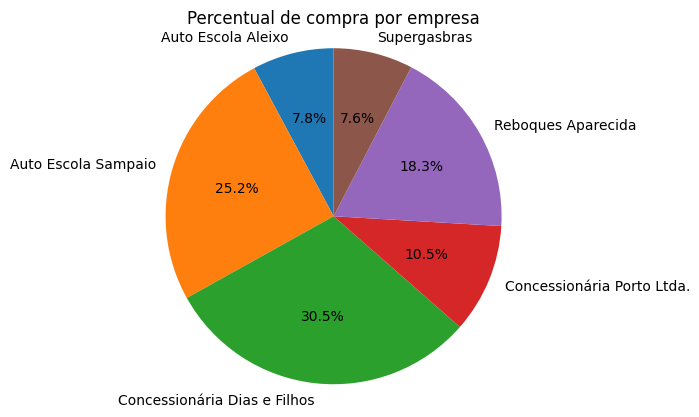

In [15]:
filtro = dds[dds['empresa'] == 'Sim']
teste = filtro.groupby('cliente')['vr_total'].sum()

plt.pie(teste, labels=teste.index, autopct='%1.1f%%',startangle=90)
plt.title('Percentual de compra por empresa')
plt.axis('equal')
plt.show()


#Histograma demonstrando a distribuição da quantidade de unidades por venda com todos os anos juntos:



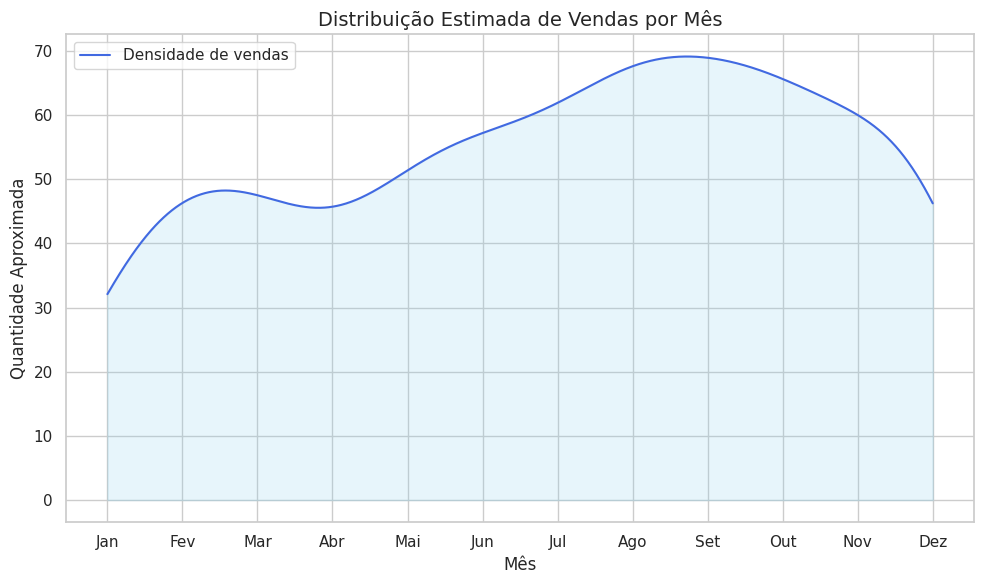

In [16]:
from scipy.stats import gaussian_kde



dds['data_compra'] = pd.to_datetime(dds['data_compra'], format='%d/%m/%Y', errors='coerce')

filtro = dds['data_compra'].dropna()
meses = filtro.dt.month


kde = gaussian_kde(meses)
x = np.linspace(1, 12, 1000)
y = kde(x) * len(meses)


sns.set(style="whitegrid")


plt.figure(figsize=(10, 6))
plt.plot(x, y, color='royalblue', label='Densidade de vendas')
plt.fill_between(x, y, alpha=0.2, color='skyblue')

plt.title('Distribuição Estimada de Vendas por Mês', fontsize=14)
plt.xlabel('Mês', fontsize=12)
plt.ylabel('Quantidade Aproximada', fontsize=12)
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun',
                                       'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez'])
plt.legend()
plt.tight_layout()
plt.show()


# Gráfico de linha comparando o volume de vendas por mês em diferentes anos


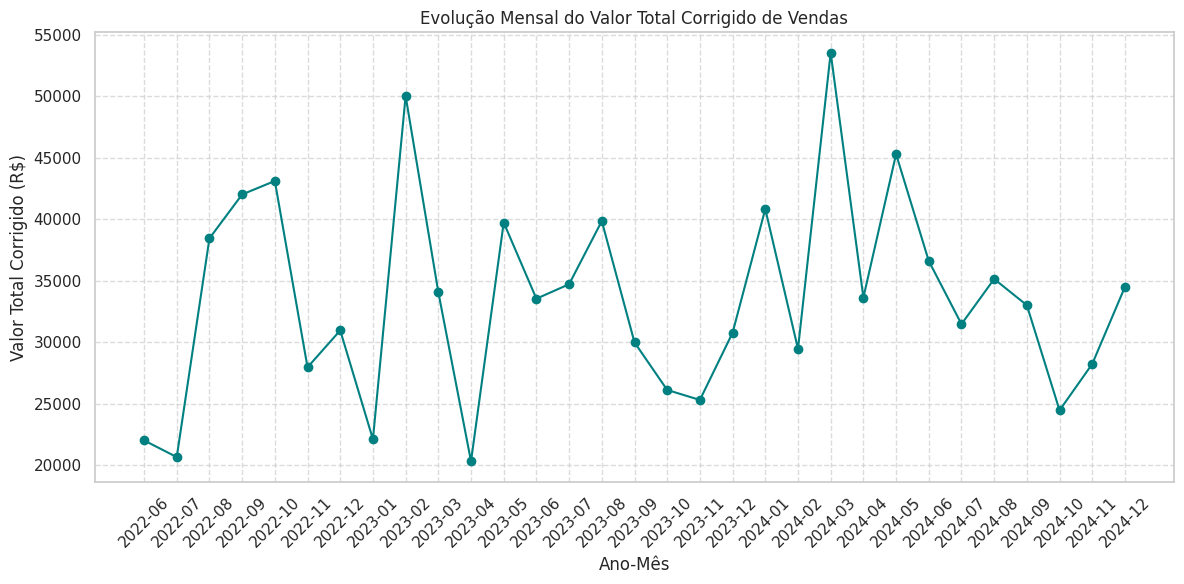

In [17]:

dds['data_compra'] = pd.to_datetime(dds['data_compra'], format='%d/%m/%Y', errors='coerce')


dds['ano_mes'] = dds['data_compra'].dt.to_period('M')


evolucao = dds.groupby('ano_mes')['vr_total'].sum().sort_index()

plt.figure(figsize=(12, 6))
plt.plot(evolucao.index.astype(str), evolucao.values, marker='o', linestyle='-', color='teal')

plt.title('Evolução Mensal do Valor Total Corrigido de Vendas')
plt.xlabel('Ano-Mês')
plt.ylabel('Valor Total Corrigido (R$)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


#Histograma, demonstrando a tendencia de compras de unidades:


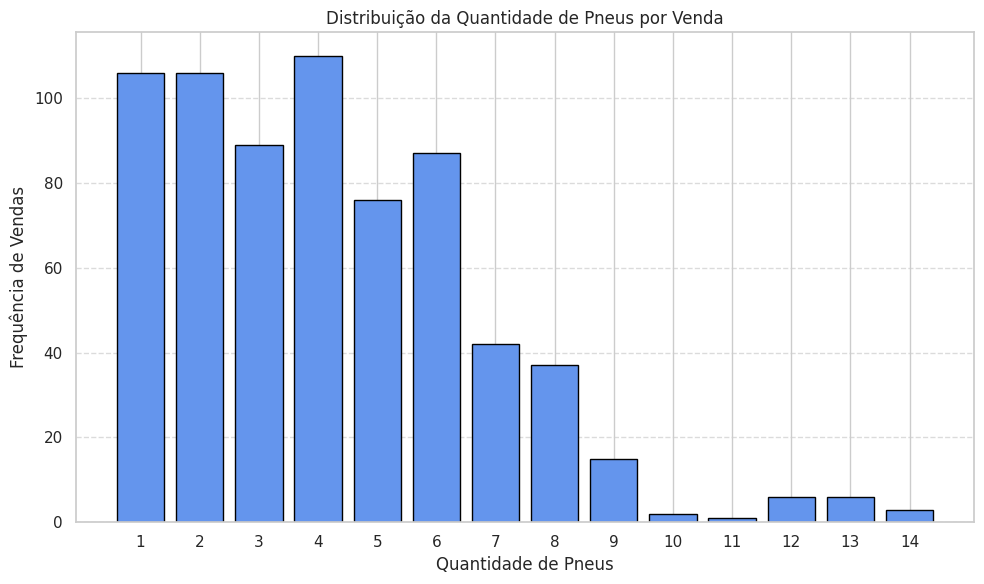

In [18]:

# Descobrir o valor máximo real de unidades vendidas por compra
max_qnt_vendas = dds['qnt_vendas'].max()

# Construir o histograma com bins até o valor máximo
bins = [i - 0.5 for i in range(1, max_qnt_vendas + 2)]

plt.figure(figsize=(10, 6))
plt.hist(dds['qnt_vendas'], bins=bins, edgecolor='black', color='cornflowerblue', rwidth=0.8)

plt.title('Distribuição da Quantidade de Pneus por Venda')
plt.xlabel('Quantidade de Pneus')
plt.ylabel('Frequência de Vendas')
plt.xticks(range(1, max_qnt_vendas + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


In [19]:
pip install requests beautifulsoup4 wordcloud matplotlib

# Descoberta de Padrões de Compra: Mineração de Regras de Associação

In [20]:
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter  # Biblioteca usada para limitar repetições de padrões nos itens

# Mineração de regras de associação é uma técnica para descobrir relações frequentes entre variáveis em grandes conjuntos de dados. Aqui, aplicamos isso para encontrar padrões de comportamento em compras de pneus.

dds_assoc = pd.DataFrame()
dds_assoc['comprou_remolde'] = dds['remolde'].astype(str).str.lower() == 'sim'
dds_assoc['comprou_mais_4_pneus'] = dds['qnt_vendas'] > 4
dds_assoc['fez_balanceamento'] = pd.to_numeric(dds['balanceamento'], errors='coerce') > 0
dds_assoc['aro_maior_que_16'] = pd.to_numeric(dds['aro'], errors='coerce') > 16
dds_assoc['compra_acima_2000'] = pd.to_numeric(dds['vr_total'], errors='coerce') > 2000
dds_assoc['comprou_pouco_sem_balancear'] = (dds['qnt_vendas'] < 2) & (pd.to_numeric(dds['balanceamento'], errors='coerce') == 0)

porte = dds['veiculo_porte'].astype(str).str.lower()
dds_assoc['carro_medio'] = porte == 'medio'
dds_assoc['caminhao_grande'] = porte == 'grande'

# Ver quantas vezes cada item aparece (frequência total)
frequencia = dds_assoc.sum()

print("=" * 60)
print(f"| {'Item':<40} | {'Frequência':>10} |")
print("=" * 60)
for item, valor in frequencia.items():
    print(f"| {item:<40} | {int(valor):>10} |")
print("=" * 60)

# Visualizar as primeiras linhas (amostra dos dados binarizados)
print("\nAmostra das primeiras 5 linhas da base (binarizada):")
print("=" * (12 + len(dds_assoc.columns) * 12))
header = " | ".join(f"{col[:10]:<10}" for col in dds_assoc.columns)
print(f"| {'Index':<6} | {header} |")
print("=" * (12 + len(dds_assoc.columns) * 12))
for idx, row in dds_assoc.head().iterrows():
    linha = " | ".join(f"{int(val):<10}" for val in row)
    print(f"| {idx:<6} | {linha} |")
print("=" * (12 + len(dds_assoc.columns) * 12))





| Item                                     | Frequência |
| comprou_remolde                          |        355 |
| comprou_mais_4_pneus                     |        275 |
| fez_balanceamento                        |        544 |
| aro_maior_que_16                         |        114 |
| compra_acima_2000                        |        203 |
| comprou_pouco_sem_balancear              |          0 |
| carro_medio                              |        335 |
| caminhao_grande                          |        351 |

Amostra das primeiras 5 linhas da base (binarizada):
| Index  | comprou_re | comprou_ma | fez_balanc | aro_maior_ | compra_aci | comprou_po | carro_medi | caminhao_g |
| 0      | 1          | 1          | 1          | 0          | 0          | 0          | 1          | 0          |
| 1      | 0          | 1          | 1          | 0          | 1          | 0          | 0          | 1          |
| 2      | 0          | 1          | 1          | 0          | 0          | 0  

,antecedents,consequents,support,confidence,lift
243,"(comprou_remolde, fez_balanceamento, compra_ac...","(caminhao_grande, comprou_mais_4_pneus)",0.065598,0.584416,2.843327
260,"(caminhao_grande, comprou_mais_4_pneus)","(comprou_remolde, fez_balanceamento, compra_ac...",0.065598,0.319149,2.843327
160,"(caminhao_grande, comprou_mais_4_pneus)","(comprou_remolde, compra_acima_2000)",0.065598,0.319149,2.806874
163,"(comprou_remolde, compra_acima_2000)","(caminhao_grande, comprou_mais_4_pneus)",0.065598,0.576923,2.806874
249,"(caminhao_grande, comprou_mais_4_pneus, fez_ba...","(comprou_remolde, compra_acima_2000)",0.065598,0.319149,2.806874
254,"(comprou_remolde, compra_acima_2000)","(caminhao_grande, comprou_mais_4_pneus, fez_ba...",0.065598,0.576923,2.806874
231,"(aro_maior_que_16, fez_balanceamento)","(caminhao_grande, compra_acima_2000)",0.064140,0.500000,2.744000
230,"(caminhao_grande, compra_acima_2000)","(aro_maior_que_16, fez_balanceamento)",0.064140,0.352000,2.744000
232,"(aro_maior_que_16, compra_acima_2000)","(caminhao_grande, fez_balanceamento)",0.064140,1.000000,2.503650
229,"(caminhao_grande, fez_balanceamento)","(aro_maior_que_16, compra_acima_2000)",0.064140,0.160584,2.503650


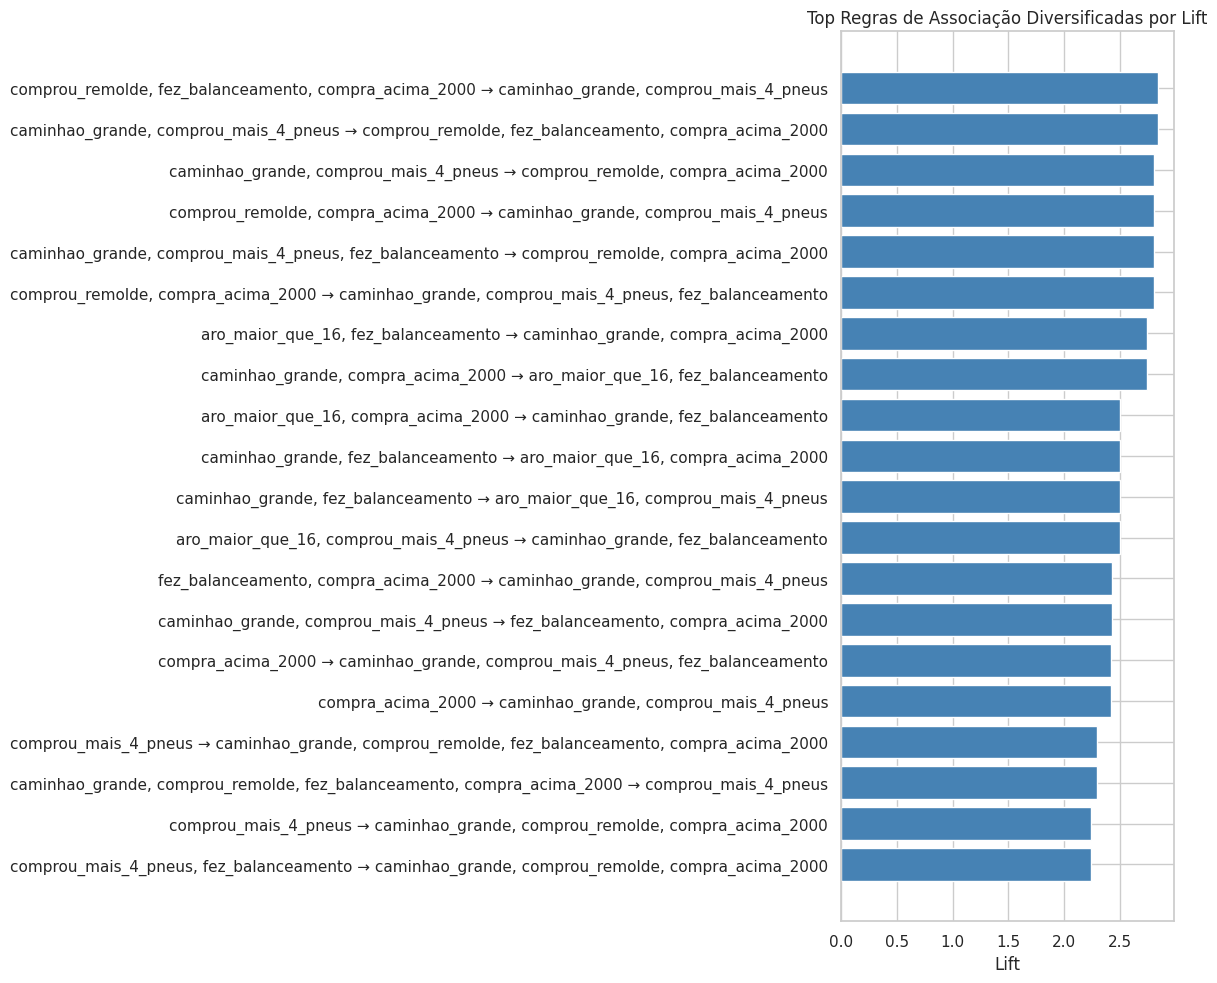

In [21]:
frequentes = apriori(dds_assoc, min_support=0.05, use_colnames=True)
regras = association_rules(frequentes, metric="lift", min_threshold=1)

top_regras = regras.sort_values(by="lift", ascending=False)

limite_por_item = 2
contagem_itens = Counter()
regras_filtradas = []

# Seleciona até 20 regras únicas, limitando repetições excessivas dos mesmos padrões
for _, regra in top_regras.iterrows():
    antecedentes = tuple(sorted(regra['antecedents']))
    consequentes = tuple(sorted(regra['consequents']))

    if contagem_itens[antecedentes] < limite_por_item or contagem_itens[consequentes] < limite_por_item:
        regras_filtradas.append(regra)
        contagem_itens[antecedentes] += 1
        contagem_itens[consequentes] += 1

    if len(regras_filtradas) >= 20:
        break

regras_selecionadas = pd.DataFrame(regras_filtradas)

display(regras_selecionadas[['antecedents', 'consequents', 'support', 'confidence', 'lift']])

plt.figure(figsize=(12, max(6, 0.5 * len(regras_selecionadas))))
plt.barh(range(len(regras_selecionadas)), regras_selecionadas['lift'], color='steelblue')
plt.yticks(
    range(len(regras_selecionadas)),
    [f"{', '.join(list(a))} → {', '.join(list(c))}"
     for a, c in zip(regras_selecionadas['antecedents'], regras_selecionadas['consequents'])]
)
plt.xlabel("Lift")
plt.title("Top Regras de Associação Diversificadas por Lift")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


#Nuvem de palavras demonstrando os termos mais frequentes nos dados coletados:


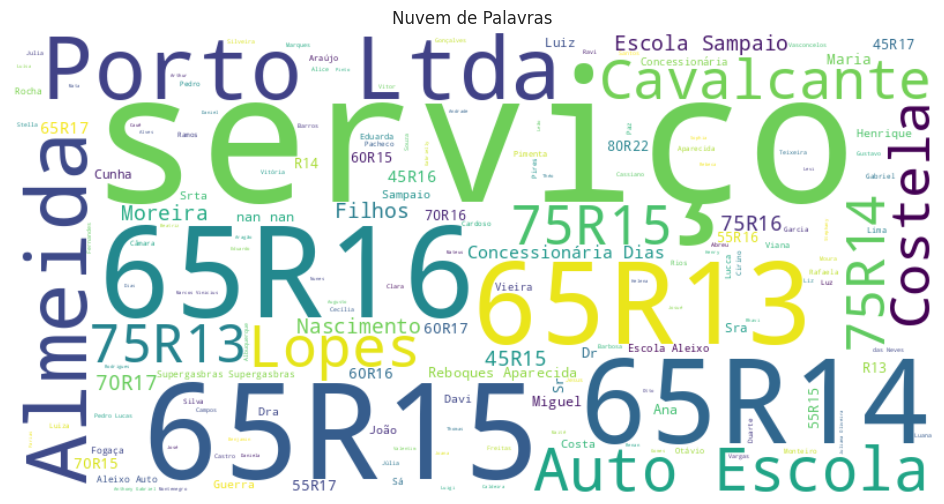

In [22]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

texto_completo = ' '.join(dds[col].astype(str).str.cat(sep=' ') for col in dds.columns)

# Stopwords básicas
stopwords = set(STOPWORDS)
stopwords.update(["de", "do", "da", "e", "a", "o", "como", "muito", "Sim", "Não", "Grande", "Medio","Sem"])

# Criar a nuvem
nuvem = WordCloud(stopwords=stopwords,
                  background_color='white',
                  width=800,
                  height=400).generate(texto_completo)

# Mostrar
plt.figure(figsize=(12, 6))
plt.imshow(nuvem, interpolation='bilinear')
plt.axis('off')
plt.title("Nuvem de Palavras")
plt.show()